# scPRS Tutorial

**Single-cell Polygenic Risk Scores** (scPRS) is a graph neural network framework that computes cell-resolved PRSs by integrating reference scATAC-seq profiles [(Zhang et al. 2025)](https://doi.org/10.1038/s41587-025-02725-6). This tutorial mirrors the paper's validation experiment using a public 10XGenomics. For demonstration purposes, we restrict the analysis to 500 cells.  

The scPRS pipeline has two clearly separated phases:

| Phase | What it does | Runtime | Where to run |
|-------|-------------|---------|---------------|
| **1. PLINK C+T per cell** | Clumps & scores GWAS variants within each cell's open-chromatin peaks | Hours–days for thousands of cells | Cluster array job (recommended) |
| **2. GNN training + analysis** | Reads pre-computed scores, builds kNN graph, trains scPRS, identifies disease-relevant cells | ~30 min on GPU | This notebook |

**This notebook focuses on Phase 2.** Phase 1 is assumed to have been run separately as a SLURM array job. The code to set up and submit that job is provided in the commented-out cells below.

### Environment Setup

Install scPRS via `pip install cellink[scprs]`.

In [1]:
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import muon as mu
from muon import atac as ac
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from cellink.tl.external import (
    prepare_scprs_data,
    write_slurm_array_job,
    run_scprs,
    get_disease_relevant_cells,
)
from cellink.resources import (
    get_gwas_catalog_study_summary_stats,
    get_1000genomes_plink_files,
    merge_1000g_plink_chromosomes,
)

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, frameon=False)

#Edit in your analysis
DATA_DIR = Path("scprs_data")
DATA_DIR.mkdir(exist_ok=True)
PREFIX   = "pbmc_monocyte"

PRS_DIR  = DATA_DIR / "pbmc_prs"            

ATAC_H5AD       = DATA_DIR / "pbmc_atac_annotated.h5ad"
ATAC_SMALL_H5AD = DATA_DIR / "pbmc_atac_small.h5ad"   # tutorial-only
GWAS_FILE       = DATA_DIR / "monocyte_count_gwas.tsv.gz"
PLINK_BFILE     = DATA_DIR / "1000G_EUR_merged"
N_CELLS_TUTORIAL = 500

/lustre/groups/ml01/workspace/lucas.arnoldt/cellink_pgen/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/lustre/groups/ml01/workspace/lucas.arnoldt/cellink_pgen/lib/python3.12/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


## Phase 1_ Data preparation & SLURM array job *(run once, separately)*

The code blocks below are **not executable cells**, they are reference code that you copy and run once (interactively in a Python session, or as a small CPU job on the cluster). After Phase 1 completes you return to this notebook for Phase 2.

Running Phase 1 produces:
- `scprs_data/pbmc_atac_annotated.h5ad` — preprocessed ATAC object with peak coordinates
- `cluster_jobs/scprs_tutorial_array.sh` — SLURM array script (one PLINK task per cell)

Submit the array job with the printed `sbatch` command and wait for all tasks to finish.

> **Genome build — GWAS and reference panel must match.**
>
> The critical constraint is that your GWAS summary statistics and your PLINK bfile must use the **same genome build**. Mixing builds causes position mismatches, silently near-zero PRS, and no error message.
>
> You are not limited to 1000G or to the monocyte count GWAS used here — see *Adapting to your own analysis* at the end of this notebook.

### Phase 1a · Download 10x PBMC multiome data

```python
BASE_URL = "https://cf.10xgenomics.com/samples/cell-arc/1.0.0/pbmc_granulocyte_sorted_10k"
FILES = {
    "h5":            f"{BASE_URL}/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5",
    "fragments":     f"{BASE_URL}/pbmc_granulocyte_sorted_10k_atac_fragments.tsv.gz",
    "fragments_idx": f"{BASE_URL}/pbmc_granulocyte_sorted_10k_atac_fragments.tsv.gz.tbi",
}
for name, url in FILES.items():
    dest = DATA_DIR / Path(url).name
    if not dest.exists():
        print(f"Downloading {name}...")
        subprocess.run(f"wget -q -O {dest} {url}", shell=True, check=True)
    else:
        print(f"Already downloaded: {dest.name}")
H5_FILE = DATA_DIR / "pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5"
```

### Phase 1b · RNA QC + cell type annotation

The QC thresholds and `cluster_to_celltype` mapping are specific to this PBMC dataset — adjust them based on your own dotplot. Cell type labels are **optional**: they are only used for the enrichment test in `get_disease_relevant_cells`. If you don't have matched RNA data, skip this step entirely and pass `cell_type_col=None` in Phase 2.

```python
mdata = mu.read_10x_h5(str(H5_FILE))
mdata.var_names_make_unique()

rna = mdata["rna"].copy()
rna.var["mt"] = rna.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(rna, qc_vars=["mt"], inplace=True)
sc.pp.filter_cells(rna, min_genes=200)
sc.pp.filter_genes(rna, min_cells=3)
rna = rna[rna.obs["pct_counts_mt"] < 20].copy()
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
sc.pp.scale(rna, max_value=10)
sc.tl.pca(rna)
sc.pp.neighbors(rna)
sc.tl.leiden(rna, resolution=0.5)
sc.tl.umap(rna)

# Visualise marker genes, then fill in the mapping below
marker_genes = {
    "CD14 Mono": ["CD14", "LYZ"],  "CD16 Mono": ["FCGR3A", "MS4A7"],
    "cDC2":      ["FCER1A", "CST3"], "NK":        ["GNLY", "NKG7"],
    "CD4 T":     ["IL7R", "CD3D"],  "CD8 T":     ["CD8A"],
    "B cell":    ["MS4A1"],
}
sc.pl.dotplot(rna, var_names=marker_genes, groupby="leiden", standard_scale="var")

# Adjust this mapping based on the dotplot above
cluster_to_celltype = {
    "0": "CD4 T", "1": "CD4 T", "2": "NK",    "3": "B cell",
    "4": "CD14 Mono", "5": "CD8 T", "6": "CD16 Mono",
    "7": "B cell", "8": "cDC2",  "9": "CD4 T",
}
rna.obs["cell_type"] = rna.obs["leiden"].map(cluster_to_celltype).fillna("Other")
sc.pl.umap(rna, color="cell_type")
```

### Phase 1c · ATAC QC + LSI embedding

The `chrom`, `start`, `end` columns in `adata.var` are required by `write_slurm_array_job`. The parsing below assumes peak names in the format `chrN:start-end` (standard 10x output). Label transfer from RNA is optional — skip the last block if you have no cell type annotations.

```python
atac = mdata["atac"].copy()
sc.pp.calculate_qc_metrics(atac, inplace=True)
mu.pp.filter_obs(atac, "n_genes_by_counts", lambda x: (x >= 500) & (x <= 50000))

ac.pp.tfidf(atac, scale_factor=1e4)
ac.tl.lsi(atac)
atac.obsm["X_lsi"] = atac.obsm["X_lsi"][:, 1:]  # drop depth-correlated component

sc.pp.neighbors(atac, use_rep="X_lsi", n_neighbors=25, n_pcs=20)
sc.tl.umap(atac)

# Parse peak coordinates — required by write_slurm_array_job
parts = atac.var_names.str.replace(":", "-").str.split("-")
atac.var["chrom"] = parts.str[0].str.replace("chr", "", regex=False)
atac.var["start"] = parts.str[1].astype(int)
atac.var["end"]   = parts.str[2].astype(int)

# Transfer cell type labels from RNA (optional)
shared = atac.obs_names.intersection(rna.obs_names)
atac   = atac[shared].copy()
atac.obs["cell_type"] = rna.obs.loc[shared, "cell_type"]

atac.write_h5ad(str(ATAC_H5AD))
print(atac)
```

### Phase 1d · GWAS + reference panel + donor labels + SLURM array job

```python
# ── GWAS summary statistics ──────────────────────────────────────────────────
# genome_build MUST match your reference panel (GRCh37 for 1000G Phase3).
# Supply any tab-separated summary statistics file with columns `CHR`, `BP`, `A1`, `A2`, `BETA`/`OR`, and `P` directly as `gwas_file`.
gwas_df = get_gwas_catalog_study_summary_stats("GCST90002305", genome_build="GRCh37")
gwas_df.to_csv(GWAS_FILE, sep="\t", index=False)

# ── Reference panel ──────────────────────────────────────────────────────────
# Use any reference panel available to you.
plink_dir, prefix = get_1000genomes_plink_files(population="EUR")
PLINK_BFILE = merge_1000g_plink_chromosomes(plink_dir, prefix, DATA_DIR / "1000G_EUR_merged")

# ── Donor labels ─────────────────────────────────────────────────────────────
# labels: pd.Series indexed by donor IDs (= .fam IID), values 1=case / 0=control.
fam = pd.read_csv(str(PLINK_BFILE) + ".fam", sep=" ", header=None,
                  names=["FID", "IID", "PAT", "MAT", "SEX", "PHENO"])
donor_ids = fam["IID"].astype(str).tolist()
np.random.seed(42)
labels = pd.Series(   # ← PLACEHOLDER — replace with real phenotypes
    np.random.choice([0, 1], size=len(donor_ids), p=[0.5, 0.5]),
    index=donor_ids, name="label",
)

# ── Tutorial-only: subsample for speed ───────────────────────────────────────
# Skip for real analyses — pass the full atac object to write_slurm_array_job.
atac_small = sc.read_h5ad(str(ATAC_H5AD))
if atac_small.n_obs > N_CELLS_TUTORIAL:
    sc.pp.subsample(atac_small, n_obs=N_CELLS_TUTORIAL, random_state=0)
atac_small.write_h5ad(str(ATAC_SMALL_H5AD))

# ── SLURM array job ───────────────────────────────────────────────────────────
# Adjust slurm_partition / slurm_qos for your cluster (check with `sinfo`).
# No SLURM? See Adapting section — the commands_file works with any scheduler.
result = write_slurm_array_job(
    adata=atac_small,           # real analysis: use atac (full object)
    gwas_file=str(GWAS_FILE),
    plink_bfile=str(PLINK_BFILE),
    prs_dir=str(PRS_DIR),       # ← must match PRS_DIR in the imports cell
    output_dir="cluster_jobs/",
    job_name="scprs_tutorial",
    slurm_partition="cpu_p",    # ← cluster-specific: check with sinfo
    slurm_qos="cpu_normal",     # ← cluster-specific: check with sinfo
    slurm_mem="8G",             # increase to 32G+ for large cohorts
    slurm_cpus=4,               # must match plink_threads
    plink_threads=4,
    slurm_time="02:00:00",
    extra_sbatch_lines=["#SBATCH --nice=0"],
)
print(f"\nSLURM:     sbatch {result['script_file']}")
print(f"Non-SLURM: bash   {result['commands_file']}")
print("Wait for all tasks to finish, then continue to Phase 2.")
```

## Phase 2: scPRS Analysis

Start here once the SLURM array job from Phase 1 has completed and PLINK score files exist under `scprs_data/pbmc_prs/`.

### 1 · Load pre-computed data

In [ ]:
# In a real analysis, replace this block:
# Load the ATAC object that was used in Phase 1 (same object passed to
# write_slurm_array_job). For a real analysis there is no subsampling:
#
#   atac = sc.read_h5ad("my_atac_annotated.h5ad")
#
# The fallback below reconstructs the tutorial's subsampled object from the
# full h5ad if the small file wasn't saved by Phase 1.
if ATAC_SMALL_H5AD.exists():
    atac_small = sc.read_h5ad(str(ATAC_SMALL_H5AD))
else:
    print(f"{ATAC_SMALL_H5AD.name} not found — reconstructing from {ATAC_H5AD.name}")
    atac_small = sc.read_h5ad(str(ATAC_H5AD))
    if atac_small.n_obs > N_CELLS_TUTORIAL:
        sc.pp.subsample(atac_small, n_obs=N_CELLS_TUTORIAL, random_state=0)
    atac_small.write_h5ad(str(ATAC_SMALL_H5AD))

print(atac_small)
print(atac_small.obs["cell_type"].value_counts())

# For a real analysis, load actual case/control phenotypes instead:
fam = pd.read_csv(
    str(PLINK_BFILE) + ".fam", sep=" ", header=None,
    names=["FID", "IID", "PAT", "MAT", "SEX", "PHENO"],
)
donor_ids = fam["IID"].astype(str).tolist()
np.random.seed(42)
labels = pd.Series(   
    np.random.choice([0, 1], size=len(donor_ids), p=[0.5, 0.5]),
    index=donor_ids, name="label",
)
print(f"Donors: {len(donor_ids)}  Cases: {labels.sum()}  Controls: {(labels==0).sum()}")

### 2 · Build PRS feature matrix

Reads the pre-computed PLINK score files and assembles the `(n_samples, n_cells, n_features)` tensor. PLINK is **not** re-run.

In [7]:
pkl_path = prepare_scprs_data(
    adata=atac_small,
    labels=labels,
    gwas_file=str(GWAS_FILE),
    prefix=PREFIX,
    prs_dir=str(PRS_DIR), # reads pre-computed files, skips PLINK
    p_thresholds=[1e-5, 1e-4, 1e-3, 0.01, 0.05, 0.1, 0.5],
    r2_thresholds=[0.1, 0.3, 0.5],
    knn_n_neighbors=25,
    n_pcs_knn=20,
)
print(f"Data pickle: {pkl_path}")

[2026-05-26 15:18:50,419] INFO:cellink.tl.external._scprs: Building kNN graph (k=25) from embedding of shape (500, 20).
[2026-05-26 15:18:51,838] INFO:cellink.tl.external._scprs: kNN graph: 12500 edges over 500 cells.
[2026-05-26 15:18:51,839] INFO:cellink.tl.external._scprs: Using pre-computed PRS score files from scprs_data/pbmc_prs.
[2026-05-26 15:27:53,905] INFO:cellink.tl.external._scprs: Saved scPRS data to pbmc_monocyte_scprs_data.pkl  X=(489, 500, 21)  y=(489,)  edges=(12500, 2)
Data pickle: pbmc_monocyte_scprs_data.pkl


### 3 · Train the scPRS GNN

In [8]:
weights_df = run_scprs(
    data_path=pkl_path,
    prefix=PREFIX,
    n_epoch=350,
    n_repeats=100,  
    layer=3,
    device="cuda:0", # falls back to CPU automatically
)
print(f"Weights shape: {weights_df.shape}  (repeats × cells)")

[2026-05-26 15:28:14,667] INFO:cellink.tl.external._scprs: Loading data from pbmc_monocyte_scprs_data.pkl


scPRS repeats: 100%|██████████| 100/100 [27:40<00:00, 16.60s/it]


[2026-05-26 15:56:11,696] INFO:cellink.tl.external._scprs: Saved cell weights to pbmc_monocyte_scprs_weights.csv
Weights shape: (100, 500)  (repeats × cells)


### 4 · Identify disease-relevant cells

Expected result: scPRS-selected cells should be strongly enriched in monocytes. Please note that we have artificially subsampled the dataset, so the results are not interpretable. Cell type annotations are optional. Pass `cell_type_col=None` (or omit it) to `get_disease_relevant_cells` if your ATAC object has no cell type labels. You will receive per-cell results without the enrichment test.

In [9]:
cell_results, ct_results = get_disease_relevant_cells(
    weights_df=weights_df,
    adata=atac_small,
    top_percentile=85.0,   
    fdr_threshold=0.1,
    cell_type_col="cell_type",
)

n_sel = cell_results["is_disease_relevant"].sum()
print(f"Disease-relevant cells: {n_sel} / {len(cell_results)} ({100*n_sel/len(cell_results):.1f}%)")

mono_types = ["CD14 Mono", "CD16 Mono", "cDC2"]
print("\nMonocyte enrichment (paper: OR~39, P<1e-50 for 10k cells):")
print(ct_results.loc[ct_results.index.isin(mono_types),
                     ["n_selected", "OR", "pval_adj", "significant"]])

Disease-relevant cells: 54 / 500 (10.8%)

Monocyte enrichment (paper: OR~39, P<1e-50 for 10k cells):
           n_selected        OR  pval_adj  significant
cell_type                                             
cDC2                2  0.970588  0.945163        False
CD14 Mono           3  0.465882  0.945163        False
CD16 Mono           2  1.281065  0.945163        False


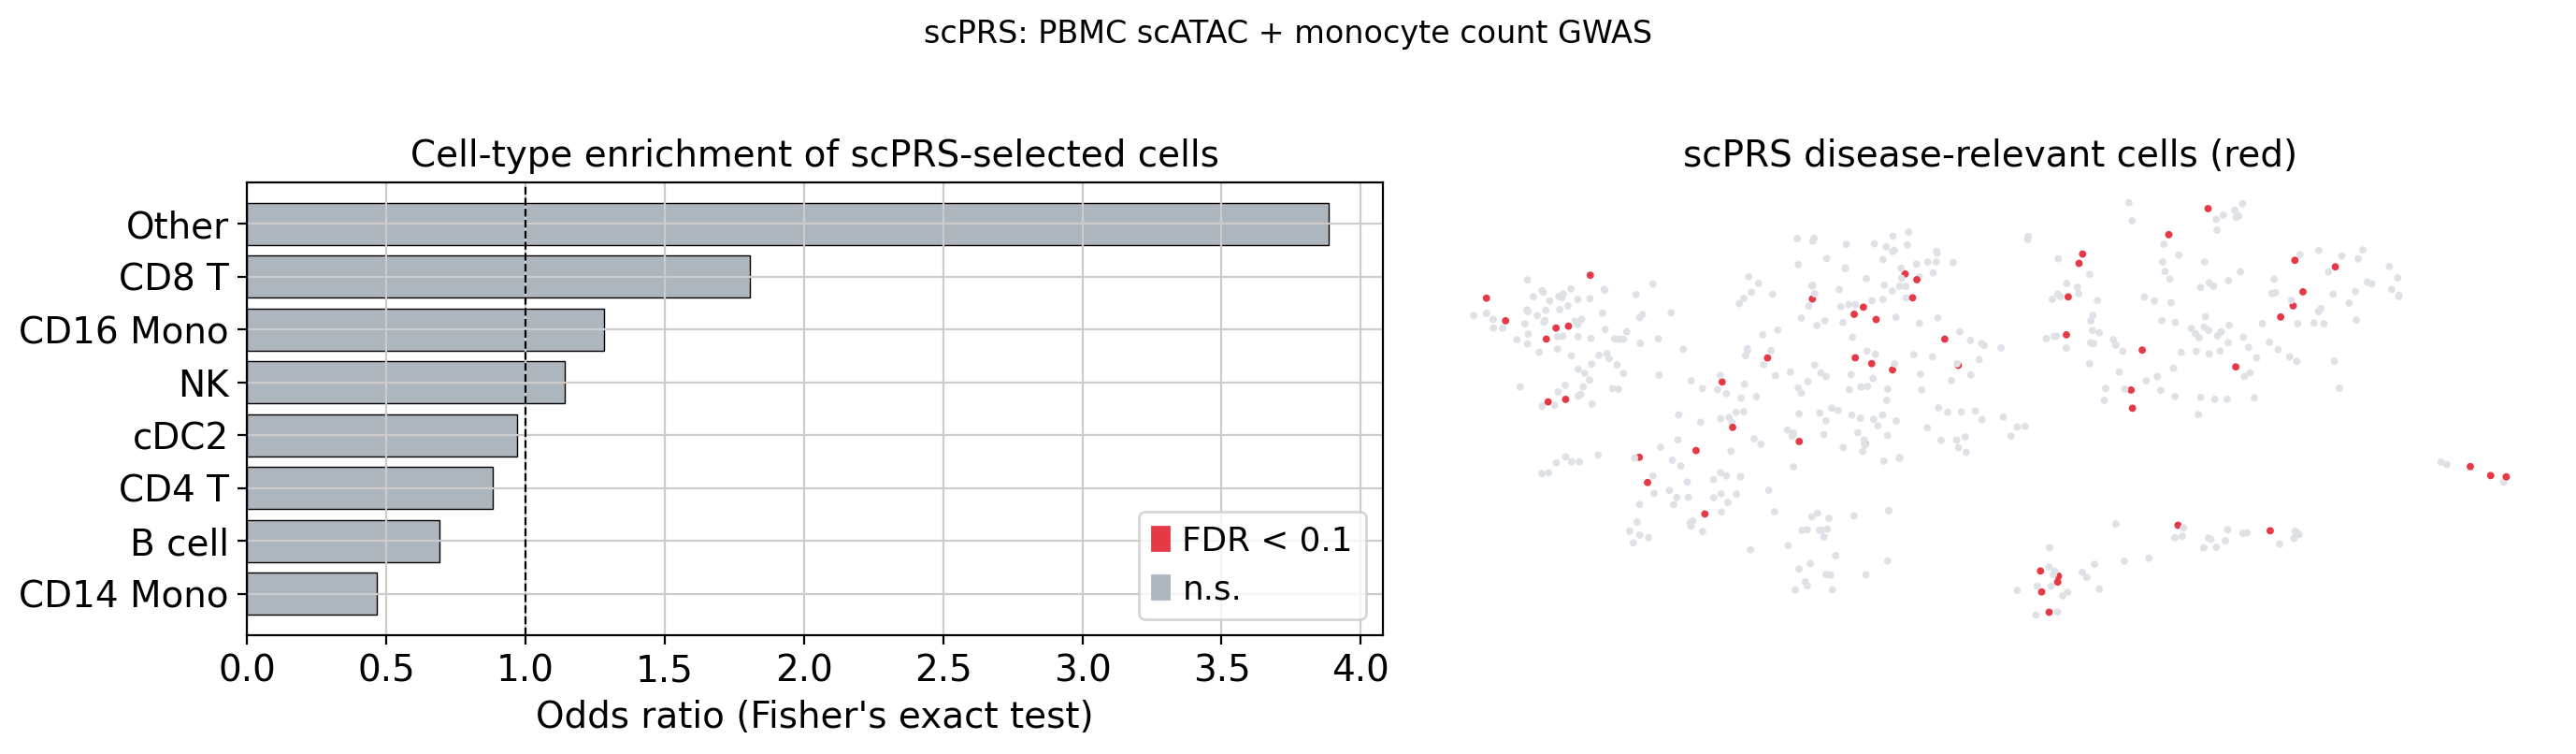

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ct_plot = ct_results.reset_index().sort_values("OR", ascending=True)
colors  = ["#e63946" if s else "#adb5bd" for s in ct_plot["significant"]]
axes[0].barh(ct_plot["cell_type"], ct_plot["OR"], color=colors, edgecolor="k", linewidth=0.5)
axes[0].axvline(1, color="k", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("Odds ratio (Fisher's exact test)")
axes[0].set_title("Cell-type enrichment of scPRS-selected cells")
axes[0].legend(handles=[
    Patch(color="#e63946", label="FDR < 0.1"),
    Patch(color="#adb5bd", label="n.s."),
])

atac_small.obs["scprs_relevant"] = cell_results["is_disease_relevant"].values
colors_rel = ["#e63946" if r else "#dee2e6" for r in atac_small.obs["scprs_relevant"]]
axes[1].scatter(
    atac_small.obsm["X_umap"][:, 0], atac_small.obsm["X_umap"][:, 1],
    c=colors_rel, s=8, linewidths=0,
)
axes[1].set_title("scPRS disease-relevant cells (red)")
axes[1].axis("off")

plt.suptitle("scPRS: PBMC scATAC + monocyte count GWAS", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()